<a href="https://colab.research.google.com/github/samrudhimadane6-creator/Customer-Segmentation/blob/main/NLP_Fake_News_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

print('Libraries loaded successfully!')

Libraries loaded successfully!


In [4]:
print('Upload Fake.csv and True.csv')
uploaded = files.upload()
print('Uploaded files:', list(uploaded.keys()))

Upload Fake.csv and True.csv


Saving Fake.csv to Fake (1).csv
Saving True.csv to True.csv
Uploaded files: ['Fake (1).csv', 'True.csv']


In [5]:
fake = pd.read_csv('Fake.csv')
true = pd.read_csv('True.csv')

fake['label'] = 0   # FAKE
true['label'] = 1   # REAL

df = pd.concat([fake, true], ignore_index=True)
df = df[['title', 'text', 'label']].dropna()
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print('Dataset shape:', df.shape)
display(df.head())

Dataset shape: (44898, 3)


,title,text,label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",0
1,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,1
2,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,1
3,OOPS: Trump Just Accidentally Confirmed He Le...,"On Monday, Donald Trump once again embarrassed...",0
4,Donald Trump heads for Scotland to reopen a go...,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",1


In [6]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', ' ', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['content'] = (df['title'] + ' ' + df['text']).apply(clean_text)

print(df[['content', 'label']].head())

                                             content  label
0  ben stein calls out th circuit court committed...      0
1  trump drops steve bannon from national securit...      1
2  puerto rico expects u s to lift jones act ship...      1
3  oops trump just accidentally confirmed he leak...      0
4  donald trump heads for scotland to reopen a go...      1


In [7]:
fake_part = df[df['label'] == 0].sample(min(10000, (df['label'] == 0).sum()), random_state=42)
real_part = df[df['label'] == 1].sample(min(10000, (df['label'] == 1).sum()), random_state=42)
data = pd.concat([fake_part, real_part]).sample(frac=1, random_state=42).reset_index(drop=True)

print('Working dataset:', data.shape)
print(data['label'].value_counts().rename({0:'FAKE', 1:'REAL'}))

Working dataset: (20000, 4)
label
REAL    10000
FAKE    10000
Name: count, dtype: int64


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    data['content'], data['label'], test_size=0.20,
    random_state=42, stratify=data['label']
)

print('Training samples:', len(X_train))
print('Testing samples :', len(X_test))

Training samples: 16000
Testing samples : 4000


In [9]:
vectorizer = TfidfVectorizer(
    stop_words='english',
    max_features=50000,
    ngram_range=(1, 2),
    min_df=2
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print('TF-IDF training shape:', X_train_tfidf.shape)

TF-IDF training shape: (16000, 50000)


In [10]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train_tfidf, y_train)

print('Model training completed!')

Model training completed!


Accuracy: 98.58%

Classification Report:

              precision    recall  f1-score   support

        FAKE       0.99      0.98      0.99      2000
        REAL       0.98      0.99      0.99      2000

    accuracy                           0.99      4000
   macro avg       0.99      0.99      0.99      4000
weighted avg       0.99      0.99      0.99      4000



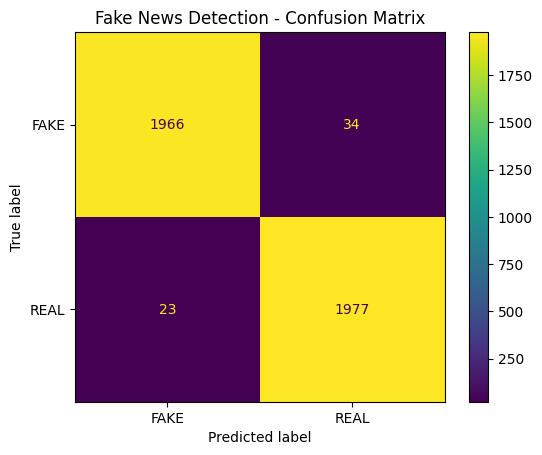

In [11]:
y_pred = model.predict(X_test_tfidf)
accuracy = accuracy_score(y_test, y_pred)

print(f'Accuracy: {accuracy * 100:.2f}%')
print('\nClassification Report:\n')
print(classification_report(y_test, y_pred, target_names=['FAKE', 'REAL']))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['FAKE', 'REAL'])
disp.plot()
plt.title('Fake News Detection - Confusion Matrix')
plt.show()

In [12]:
def predict_news(news_text):
    cleaned = clean_text(news_text)
    transformed = vectorizer.transform([cleaned])
    prediction = model.predict(transformed)[0]
    probability = model.predict_proba(transformed).max() * 100
    result = 'REAL' if prediction == 1 else 'FAKE'
    print('Prediction:', result)
    print(f'Model confidence: {probability:.2f}%')

news = '''The government announced a new technology program to support students and universities.'''
predict_news(news)

Prediction: FAKE
Model confidence: 60.91%


In [13]:
import joblib
joblib.dump(model, 'fake_news_model.pkl')
joblib.dump(vectorizer, 'tfidf_vectorizer.pkl')
print('Saved: fake_news_model.pkl and tfidf_vectorizer.pkl')

Saved: fake_news_model.pkl and tfidf_vectorizer.pkl
